In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from radmc_utils import *

In [2]:
simdir = '/Users/colinbourque/astrophysics/star-formation/SIMULATIONS'

In [3]:
## Read the grid info from the radmc3d input
## This will be cell *walls*, not center values used in calculations
rr, tt = load_amr_grid(f'{simdir}/model10/INPUT/amr_grid.430.inp', nr=130, nt=120) 

## read the dust density
rho    = load_dustdens(f'{simdir}/model10/INPUT/dust_density.430.inp', nr=130, nt=120)

## read the calculated temperatures
temps  = load_dusttemps(f'{simdir}/model10/OUTPUT/dust_temperature.430.dat', nr=130, nt=120)

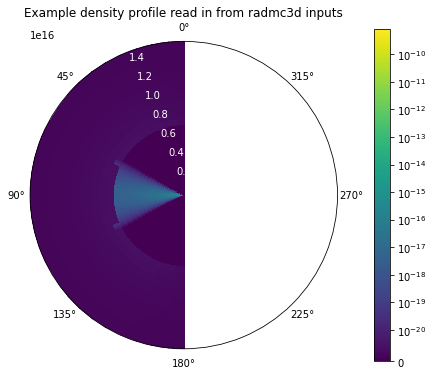

In [17]:
## Plot density profile
fig = plt.figure(figsize=[5,7])
ax = fig.add_axes([1,1,1,1],polar=True)
ax.grid(False)
ax.set_theta_zero_location("N")

## radmc3d temperatures
pcm = ax.pcolormesh(tt, rr, rho, edgecolors='face', cmap='viridis',
                    norm=colors.SymLogNorm(linthresh=1e-20, vmin=np.min(rho), vmax=np.max(rho)))

plt.colorbar(pcm, fraction=0.046, pad=0.1)

rlabels = ax.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
    
ax.set_rlim([0,1000*au])
ax.set_title(f'Example density profile read in from radmc3d inputs')

plt.show()

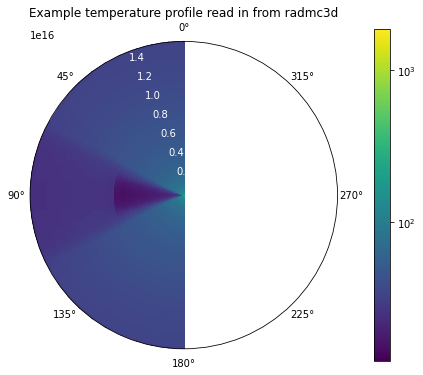

In [19]:
## Plot temperature profile
fig = plt.figure(figsize=[5,7])
ax = fig.add_axes([1,1,1,1],polar=True)
ax.grid(False)
ax.set_theta_zero_location("N")

## radmc3d temperatures
pcm = ax.pcolormesh(tt, rr, temps, edgecolors='face', cmap='viridis',
                    norm=colors.SymLogNorm(linthresh=1e-20, vmin=np.min(temps), vmax=np.max(temps)))

plt.colorbar(pcm, fraction=0.046, pad=0.1)

rlabels = ax.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
    
ax.set_rlim([0,1000*au])
ax.set_title(f'Example temperature profile read in from radmc3d')

plt.show()